# Домашнее задание 2. StarGAN

## Этап 1. Установка зависимостей, инициализация и загрузка данных

В этом разделе мы работаем с датасетом CelebA, содержащим изображения лиц с набором атрибутов. Целью задания является генерация новых изображений лиц с заданными характеристиками.

In [1]:
print(1)

1


In [2]:
import os
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import re
from PIL import Image

try:
    from natsort import natsorted
    SORT_FN = natsorted
except ImportError:
    # fallback to regular sorted if natsort is not available
    SORT_FN = sorted

import pandas as pd


class CelebADataset(Dataset):

    def __init__(self,
                 root_dir: str = "/kaggle/input/datasets/jessicali9530/celeba-dataset",
                 transform: transforms.Compose = None):
        super().__init__()
        self.root_dir = root_dir
        self.transform = transform

        self.header = None

        self.dataset_folder = os.path.join(root_dir, "img_align_celeba", "img_align_celeba")

        # Load file names
        self.filenames = os.listdir(self.dataset_folder)
        # Ensure consistent ordering (important if you rely on index-based consistency)
        self.filenames = SORT_FN(self.filenames)

        attr_file_path = os.path.join(root_dir, "list_attr_celeba.csv")
        df = pd.read_csv(attr_file_path)

        filename_col = df.columns[0]
        self.header = list(df.columns[1:])

        self.annotations = []
        for _, row in df.iterrows():
            filename = row[filename_col]
            attr_vals = [int(v) for v in row[self.header].tolist()]
            self.annotations.append((filename, attr_vals))

        # Convert to a dict: filename -> attribute tensor
        self.attr_map = {
            fn: torch.tensor(attr_vals, dtype=torch.long)
            for fn, attr_vals in self.annotations
        }

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        """
        Returns:
            tuple: (image, info_dict) where:
                image is the transformed PIL image,
                info_dict is a dictionary containing:
                    - 'filename': str
                    - 'idx': int
                    - 'attributes': torch.Tensor of shape (#attributes,)
        """
        img_name = self.filenames[idx]
        img_path = os.path.join(self.dataset_folder, img_name)

        # Load the image
        img = Image.open(img_path).convert("RGB")

        # Apply transforms
        if self.transform is not None:
            img = self.transform(img)

        # Fetch attributes (if they exist in the attr_map; some extra files might appear)
        attributes = self.attr_map.get(img_name, torch.zeros(40, dtype=torch.long))

        info_dict = {
            "filename": img_name,
            "idx": idx,
            "attributes": attributes
        }
        return img, info_dict

In [3]:
!pip install munch

In [4]:
%pip install lpips -q

import sys
sys.path.append('/kaggle/input/datasets/jessicali9530/celeba-dataset')  # Добавляем путь к CelebADataset

import torch
from lpips import LPIPS
from torchvision import transforms
from munch import Munch
from tqdm.auto import trange
import matplotlib.pyplot as plt
import numpy as np

device: str = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device(device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
device

device(type='cuda')

In [6]:
args = Munch()
args.img_size = 256  # Размер изображений после преобразования
args.batch_size=16
args.num_iters = 30000
args.lr = 0.0001
args.n_critic = 5
args.beta1 = 0.5
args.beta2 = 0.999

args.our_attrs = ["Black_Hair", "Narrow_Eyes", "Wavy_Hair", "Wearing_Lipstick", "Blond_Hair","Mouth_Slightly_Open", "Chubby", "Heavy_Makeup", "Male", "Young", "Smiling", "Eyeglasses", "Bangs", "Wearing_Hat"]

# Создание последовательности преобразований для подготовки изображений
transform=transforms.Compose([
    transforms.Resize(args.img_size),
    transforms.CenterCrop(args.img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                          std=[0.5, 0.5, 0.5])
])

# Загрузка датасета CelebA с применением указанных преобразований
dataset = CelebADataset(
    root_dir='/kaggle/input/datasets/jessicali9530/celeba-dataset',
    transform=transform)

# Число потоков для загрузки данных
num_workers = 2
# Whether to put fetched data tensors to pinned memory
pin_memory = True if device.type == 'cuda' else False

attr2idx = {name: i for i, name in enumerate(dataset.header)}
args.our_attrs_idx = [attr2idx[a] for a in args.our_attrs]

# Создание DataLoader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=args.batch_size,
    num_workers=num_workers,
    pin_memory=pin_memory,
    shuffle=True,
    drop_last=True
)

In [7]:
# args.num_domains = ...  # Задайте число доменов
args.num_domains = len(args.our_attrs) 

### Визуализация датасета

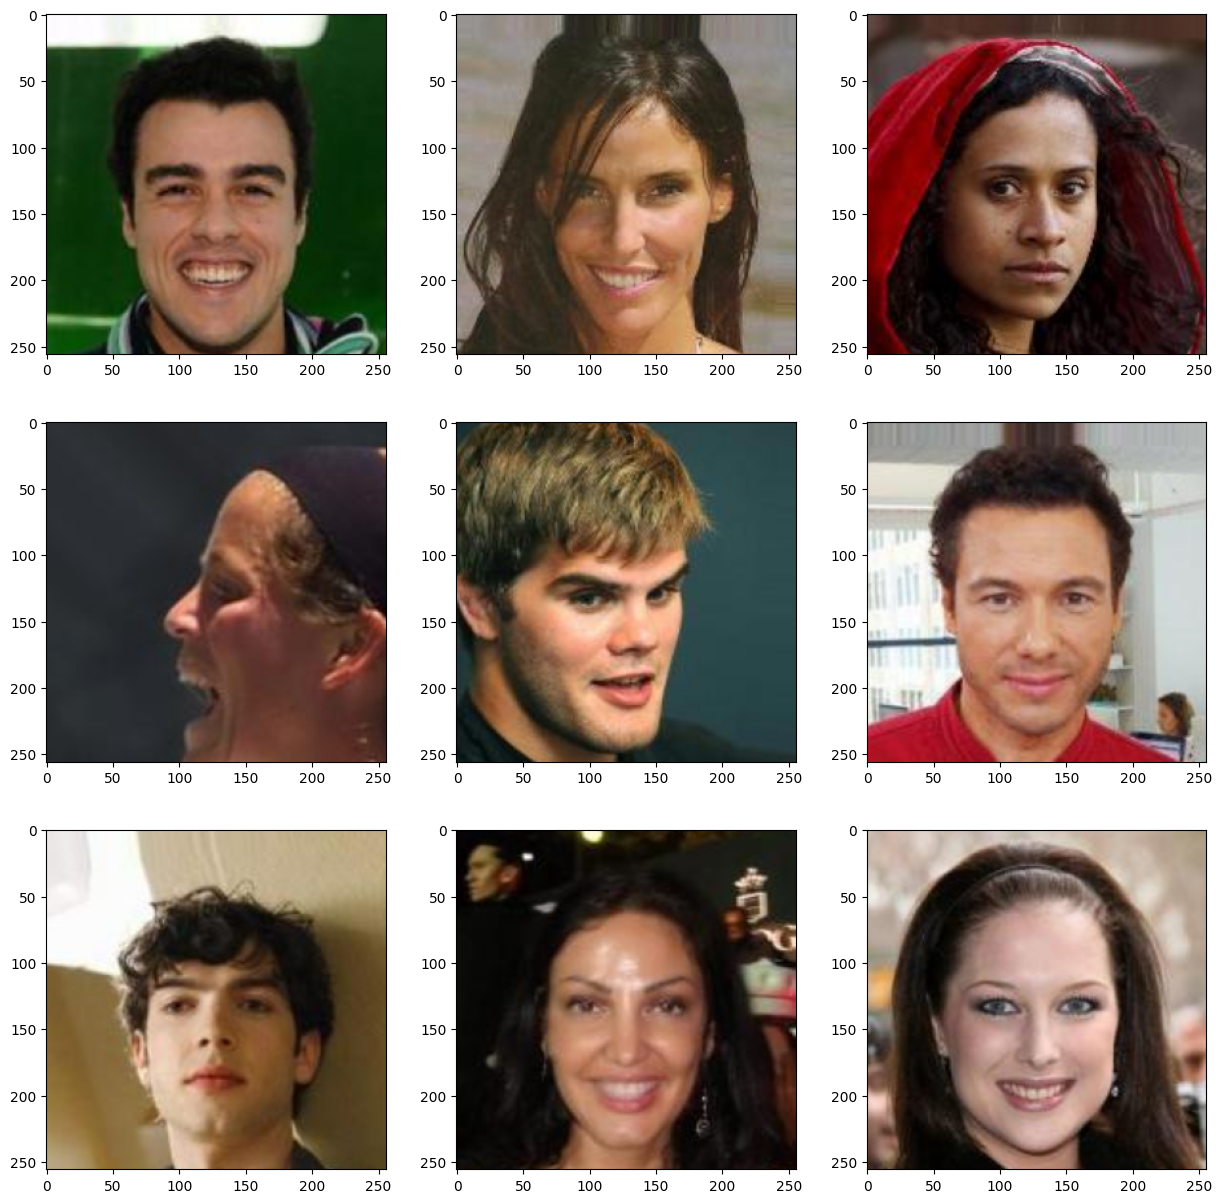

In [8]:
# Визуализация случайно выбранных изображений из датасета

_, axes = plt.subplots(ncols=3, nrows=3, figsize=(15, 15))
for i, img_idx in enumerate(np.random.choice(range(len(dataset)), 9)):

    img, target = dataset[img_idx]
    img = (img - img.min()) / (img.max() - img.min())
    axes[i // 3][i % 3].imshow(img.detach().cpu().numpy().transpose(1, 2, 0))

## Этап 2. Инициализация и обучение модели

В этом этапе необходимо реализовать и обучить модель StarGAN для генерации лиц с заданными атрибутами.

Вы можете выбрать одну из следующих моделей:
- [StarGANv1](https://arxiv.org/pdf/1711.09020.pdf) (**до 4 баллов**)
- [StarGANv2](https://arxiv.org/abs/1912.01865) (**до 7 баллов**)

### Инициализация

Ниже приведён шаблон для определения основных компонентов модели. Реализуйте их по своему усмотрению.

In [9]:
import torch.nn as nn
class ResidualBlock(nn.Module):
    def __init__(self, dim, is_leakyReLU=False):
        super().__init__()
        self.dim = dim
        self.conv1 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, stride=1)
        self.in1= nn.InstanceNorm2d(dim, affine=True)
        self.relu = nn.ReLU(inplace=True)
        if is_leakyReLU:
            self.relu = nn.LeakyReLU(0.01, inplace = True)
        self.conv2 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, stride=1)
        self.in2 = nn.InstanceNorm2d(dim, affine=True)
        
    def forward(self, x):
        out = self.in1(self.conv1(x))
        out = self.relu(out)
        out = self.in2(self.conv2(out))
        return out + x


def down_block(d_in, d_out, kernel_size, stride, padding, bias=False):
    return [
        nn.Conv2d(d_in, d_out, kernel_size=kernel_size, stride=stride, padding=padding, bias=bias),
        nn.InstanceNorm2d(d_out, affine=True),
        nn.ReLU(inplace=True)
    ]


def up_block(d_in, d_out, kernel_size, stride, padding, bias=False):
    return [
        nn.ConvTranspose2d(d_in, d_out, kernel_size=kernel_size, stride=stride, padding=padding, bias=bias),
        nn.InstanceNorm2d(d_out, affine=True),
        nn.ReLU(inplace=True),
    ]
    
def disc_block(d_in, d_out, kernel_size, stride, padding, slope=0.01):
    return [
        nn.Conv2d(d_in, d_out, kernel_size=kernel_size, stride=stride, padding=padding, bias=False),
        nn.LeakyReLU(slope, inplace=True),
    ]

    
class Generator(nn.Module):
    def __init__(self, c_dim=10, features_dim=64):
        super().__init__()
        self.c_dim = c_dim
        self.features_dim = features_dim
        down_sampling = []
        down_sampling += [
            nn.Conv2d(3 + self.c_dim, self.features_dim, kernel_size=7, padding=3, stride=1, bias=False),
            nn.InstanceNorm2d(64, affine=True),
            nn.ReLU(inplace=True)
        ]
        channels = self.features_dim
        for _ in range(2):
            down_sampling += down_block(channels, channels * 2, 4, 2, 1)
            channels *= 2
            
        residual_blocks = []
        for _ in range(6):
            residual_blocks.append(ResidualBlock(256, is_leakyReLU=False))
        up_sampling = []
        for _ in range(2):
            up_sampling += up_block(channels, channels//2, 4, 2, 1)
            channels //= 2
        
        up_sampling += [
            nn.Conv2d(channels, 3, kernel_size=7, stride=1, padding=3, bias=False),
            nn.Tanh()
        ]
        all_layers = down_sampling + residual_blocks + up_sampling
        self.layers = nn.Sequential(*all_layers)
        
    def forward(self, x, c):
        batch_size, channels, h, w = x.size()
        c = c.view(batch_size, self.c_dim,1, 1)
        c = c.expand(batch_size, self.c_dim, h, w)
        out = torch.cat([x, c], dim=1)
        return self.layers(out)
        
            

class Discriminator(nn.Module):
    def __init__(self, feature_dim=64, c_dim=10):
        super().__init__()
        self.feature_dim = feature_dim
        input_layer = [
            nn.Conv2d(3, self.feature_dim, kernel_size=4, stride=2, padding=1, bias=False), 
            nn.LeakyReLU(0.01, inplace=True)
        ]
        hidden = []
        channels = feature_dim

        # у них в репозитории почему-то 6 рипитов стоит, хотя в статье 5, поставлю 5
        for _ in range(5):
            hidden += disc_block(channels, channels*2, kernel_size=4, stride=2, padding=1)
            channels *= 2
        
        l = input_layer + hidden
        self.layers = nn.Sequential(*l)
        self.output_src = nn.Conv2d(channels, 1, kernel_size=3, stride=1, padding=1, bias=False)
        self.output_cls = nn.Conv2d(channels, c_dim, kernel_size=4, stride=1, padding=0)
    def forward(self, x):
        out = self.layers(x)
        output_src = self.output_src(out) # b, 1, h/64, w/64
        output_cls = self.output_cls(out) # b, c_dim, 1, 1
        output_cls = output_cls.view(output_cls.size(0), output_cls.size(1))
        return output_src, output_cls
        

In [10]:
nets = Munch()
nets.generator = Generator(c_dim=args.num_domains).to(device) 
nets.discriminator = Discriminator(c_dim=args.num_domains).to(device)

g_optimizer = torch.optim.Adam(nets.generator.parameters(), lr=args.lr, betas=(args.beta1, args.beta2))
d_optimizer = torch.optim.Adam(nets.discriminator.parameters(), lr=args.lr, betas=(args.beta1, args.beta2))

### Обучение

In [11]:
args.n_critic

5

In [ ]:
def save_ckpt(path, iteration, nets, g_optimizer, d_optimizer, args=None):
    ckpt = {
        "iteration": iteration,
        "G": nets.generator.state_dict(),
        "D": nets.discriminator.state_dict(),
        "opt_G": g_optimizer.state_dict(),
        "opt_D": d_optimizer.state_dict(),
    }
    torch.save(ckpt, path)

In [ ]:
import torch.nn.functional as F

lambda_cls = 1.
lambda_rec = 10.
lambda_gp = 1.

CKPT_DIR = "/kaggle/working/"
os.makedirs(CKPT_DIR, exist_ok=True)

def denormal(x):
    return (x + 1) / 2

def get_attrs(info):
   return ((info["attributes"][:, args.our_attrs_idx] + 1) // 2).float()

def gradient_penalty(out_src, x):
    grad = torch.autograd.grad(
        outputs = out_src.sum(), 
        inputs=x,
        create_graph = True,
        retain_graph=True,
        only_inputs = True   
    )[0]
    grad = grad.view(grad.size(0), -1)
    return ((grad.norm(2, dim=1) - 1) ** 2).mean()
    

nets.generator.train()
nets.discriminator.train()
data_iter = iter(dataloader)
count_iters = args.num_iters
every = 10000

for iteration in trange(count_iters):
    try:
        x_real, info = next(data_iter)
    except StopIteration:
        data_iter = iter(dataloader)
        x_real, info = next(data_iter)

    x_real = x_real.to(device)
 
    batch = x_real.size(0)

    c = get_attrs(info)
    c_gen = torch.roll(c, shifts=1, dims=0)
    
    c = c.to(device)
    c_gen = c_gen.to(device)
    # дискриминатор
    d_optimizer.zero_grad(set_to_none=True)
    output_src_real, output_cls_real = nets.discriminator(x_real)
    with torch.no_grad():
        x_fake = nets.generator(x_real, c_gen)
    output_src_fake, output_cls_fake = nets.discriminator(x_fake)
    d_loss_adv = -(output_src_real.mean() - output_src_fake.mean())
    d_loss_cls = F.binary_cross_entropy_with_logits(output_cls_real, c)
    coeff = torch.rand(batch, 1, 1, 1, device=device)
    
    x_middle = (coeff * x_real + (1 - coeff) * x_fake).requires_grad_(True)
    out_src_middle, _ = nets.discriminator(x_middle)
    d_loss_gp = gradient_penalty(out_src_middle, x_middle)
    d_loss = lambda_cls * d_loss_cls + lambda_gp * d_loss_gp + d_loss_adv
    d_loss.backward()
    d_optimizer.step()
    # генератор
    if (iteration + 1) % args.n_critic == 0:
        g_optimizer.zero_grad(set_to_none=True)
        x_fake = nets.generator(x_real, c_gen)
        output_src_fake, output_cls_fake = nets.discriminator(x_fake)
        g_loss_adv = -output_src_fake.mean()
        g_loss_cls = F.binary_cross_entropy_with_logits(output_cls_fake, c_gen)
        x_recon = nets.generator(x_fake, c)
        g_loss_rec = torch.mean(torch.abs(x_real - x_recon))
        g_loss = g_loss_adv + lambda_cls * g_loss_cls + lambda_rec * g_loss_rec
        g_loss.backward()
        g_optimizer.step()
        
    if ((iteration + 1) % every == 0) or (iteration == (count_iters - 1)):
        ckpt_path = os.path.join(CKPT_DIR, f"ckpt_stargan_iter.pt")
        save_ckpt(ckpt_path, iteration+1, nets, g_optimizer, d_optimizer)
        print(f"saved: {ckpt_path}")
        
    if ((iteration + 1) % 50 == 0) and ((iteration + 1) % args.n_critic == 0):
        text = f"""
        {iteration} / {count_iters}
        Discriminator: adv {d_loss_adv.item():.3f} cls {d_loss_cls.item():.3f} gp {d_loss_gp.item():.3f}
        Generator: adv {g_loss_adv.item():.3f} cls {g_loss_cls.item():.3f} rec {g_loss_rec.item():.3f}"""
        print(text)
            

In [12]:
def load_ckpt(path, nets, g_optimizer, d_optimizer):
    ckpt = torch.load(path, map_location=device)
    nets.generator.load_state_dict(ckpt["G"])
    nets.discriminator.load_state_dict(ckpt["D"])
    g_optimizer.load_state_dict(ckpt["opt_G"])
    d_optimizer.load_state_dict(ckpt["opt_D"])

PATH = "/kaggle/input/datasets/rdegt00/ckpt-stargan/ckpt_stargan_iter.pt"
load_ckpt(PATH, nets, g_optimizer, d_optimizer)

In [ ]:
args.our_attrs = ["Black_Hair", "Narrow_Eyes", "Wavy_Hair", "Wearing_Lipstick", "Blond_Hair","Mouth_Slightly_Open", "Chubby", "Heavy_Makeup", "Male", "Young", "Smiling", "Eyeglasses", "Bangs", "Wearing_Hat"]


In [303]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

our_attrs = args.our_attrs

def denorm(x):
    return (x + 1) / 2

def set_attr(c, attr_name,value):
    c_gen = c.clone()
    c_gen[our_attrs.index(attr_name)] = value
    return c_gen


def show_examples(attr, value=1.0):
    nets.generator.eval()
    with torch.no_grad():
        x_real, info = next(iter(dataloader))
        x = x_real[0:1].to(device)
    
        c = ((info["attributes"][0, args.our_attrs_idx] + 1) // 2).float().to(device)
        attr = attr
        c_gen = set_attr(c, attr, value).unsqueeze(0)
        x_fake = nets.generator(x, c_gen)
    
    imgs = torch.cat([denorm(x), denorm(x_fake)], dim=0)
    grid = make_grid(imgs, nrow=2)
    
    plt.figure(figsize=(12, 5))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(f"orig |  with {attr} = {value} ")
    plt.axis("off")
    plt.show()



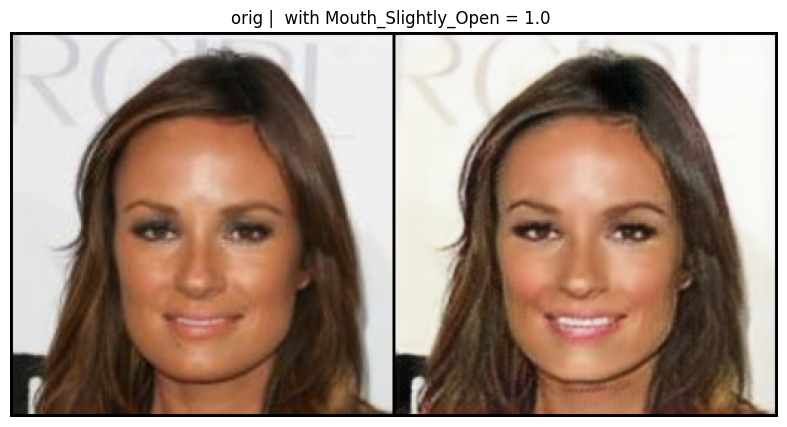

In [304]:
show_examples("Mouth_Slightly_Open")

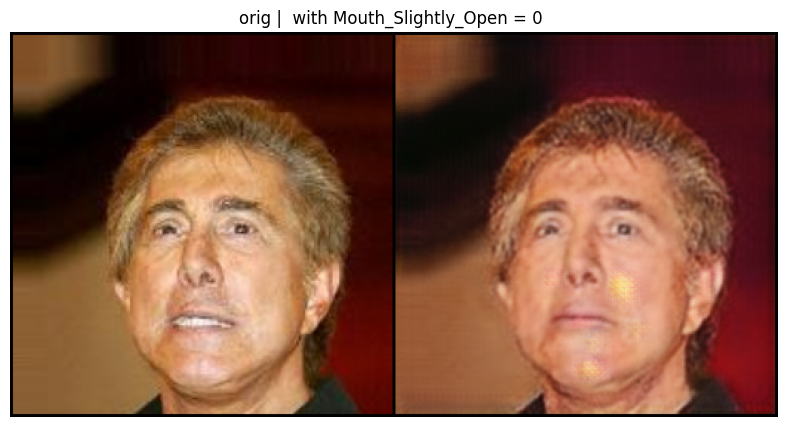

In [326]:
show_examples("Mouth_Slightly_Open", 0)

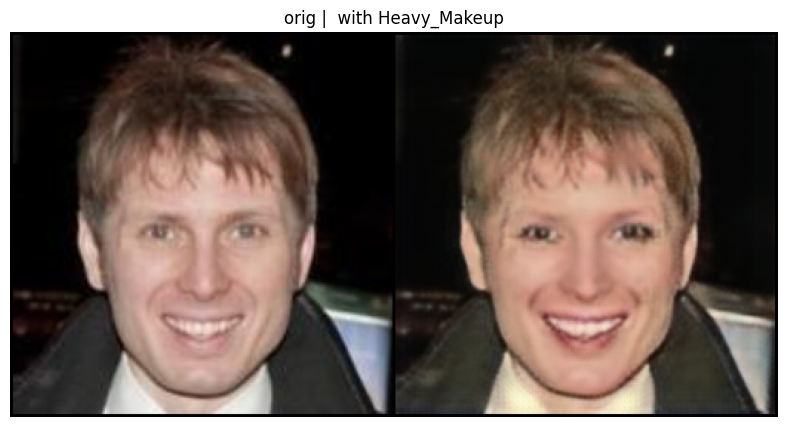

In [302]:
show_examples("Heavy_Makeup")

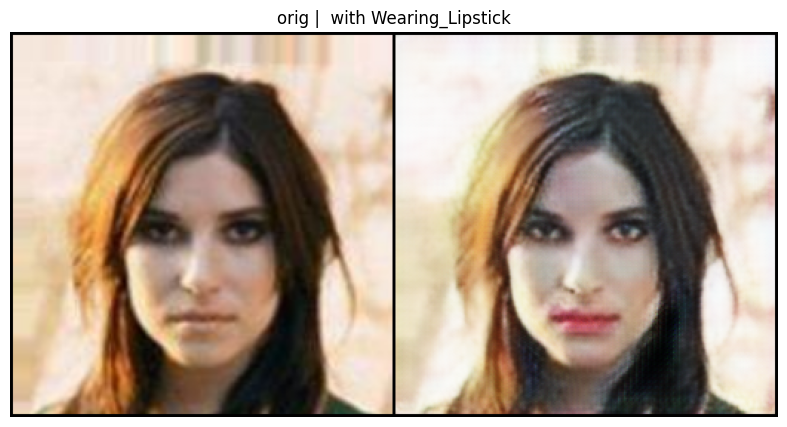

In [241]:
show_examples("Wearing_Lipstick")

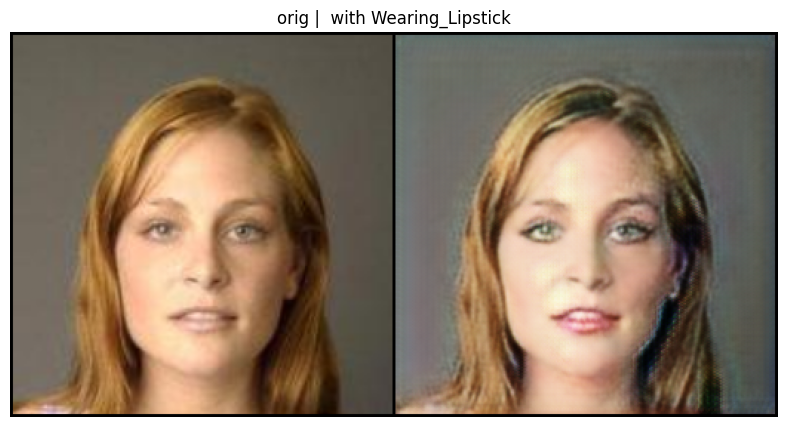

In [246]:
show_examples("Wearing_Lipstick")

**Вывод**:

ну вот модель в целом неплохо добавляет какие-то частовстречающиеся аттрибуты: улыбку/приоткрытый рот, мейкап или наоборот убирает какие-то вещи, выше пример, где улыбка наоборот убрана. Модель учил часов 7-8

### Оценка модели

Для оценки качества сгенерированных изображений используется метрика LPIPS.

In [343]:
lpips = LPIPS()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 222MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [352]:
torch.cuda.empty_cache()

In [356]:
lpips = lpips.to(device)
test_iters = 100  # Количество итераций для тестирования модели
values = []

nets.generator.eval()
for i in trange(test_iters):
    x_real, info = next(iter(dataloader))
    x_real = x_real[:4].to(device)
    c = ((info["attributes"][:4, args.our_attrs_idx] + 1) // 2).float().to(device)
    c_gen = torch.roll(c, shifts=1, dims=0)
    x_fake = nets.generator(x_real, c_gen)
    loss = lpips(x_fake, x_real)
    values.append(loss.mean().item())
    

print("Среднее значение LPIPS:", np.mean(values))
assert np.mean(values) < 1.3

  0%|          | 0/100 [00:00<?, ?it/s]

Среднее значение LPIPS: 0.13067729003727435


## Этап 3. Дополнительный анализ

В данном разделе рекомендуется провести дополнительные эксперименты и анализ:
- **Анализ латентного пространства**. *(2 балла)*
- **Текстовое ревью решения**: опишите, какие изменения можно внести для улучшения модели, и обоснуйте их. *(1 балл)*

В чате писали, что можно например, посмотреть на гладкость в переходах между атрибутами. Возьмем, например, Mouth_Slightly_Open (и другие тоже) и посмотрим как  будет меняться генерация изображений, если генерировать что-то между 1 и 0 для этого параметра

In [434]:
def set_attrs(c, info):
    c_gen = c.clone()
    for name, val in info.items():
        c_gen[selected_attrs.index(name)] = val
    return c_gen

def show_exp(attr="Mouth_Slightly_Open", count=10):
    nets.generator.eval()
    with torch.no_grad():
        x_real, info = next(iter(dataloader))
        x = x_real[:1].to(device)
        c = ((info["attributes"][0, args.our_attrs_idx] + 1) // 2).float().to(device)
    
        c_a = set_attrs(c, {attr: 0.})
        c_b = set_attrs(c, {attr: 1.})
    
        coeff = torch.linspace(0, 1, count, device=device)
        imgs = []
        imgs.append(denorm(x))
        for a in coeff:
            c_hat = ((1 - a) * c_a + a * c_b).unsqueeze(0)
            x_hat = nets.generator(x, c_hat)
            imgs.append((x_hat + 1) / 2)
    
    grid = make_grid(torch.cat(imgs, dim=0), nrow=len(imgs))
    plt.figure(figsize=(18, 3))
    plt.imshow(np.clip(grid.permute(1,2,0).cpu().numpy(), 0, 1))
    plt.title(f"Interpolation between {attr} attribute first:orig, second: {attr}=0 , last: f{attr}=1)")
    plt.axis("off")
    plt.show()

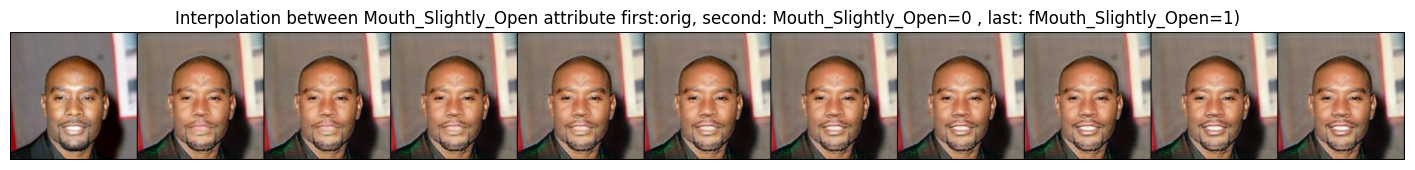

In [417]:
show_exp(attr="Mouth_Slightly_Open")

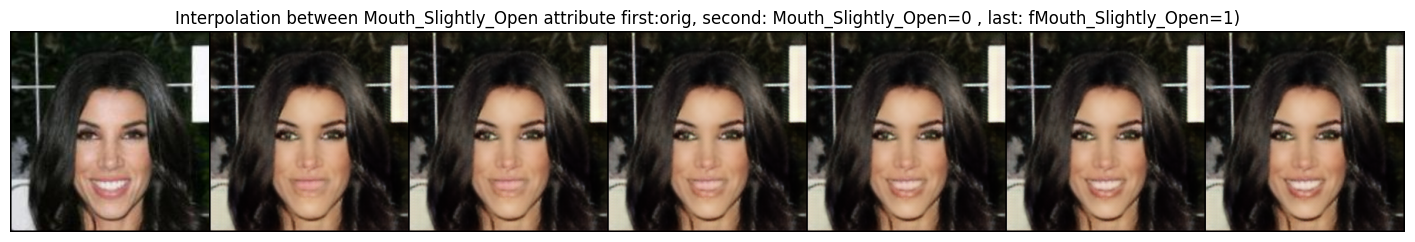

In [419]:
show_exp(attr="Mouth_Slightly_Open", count=6)

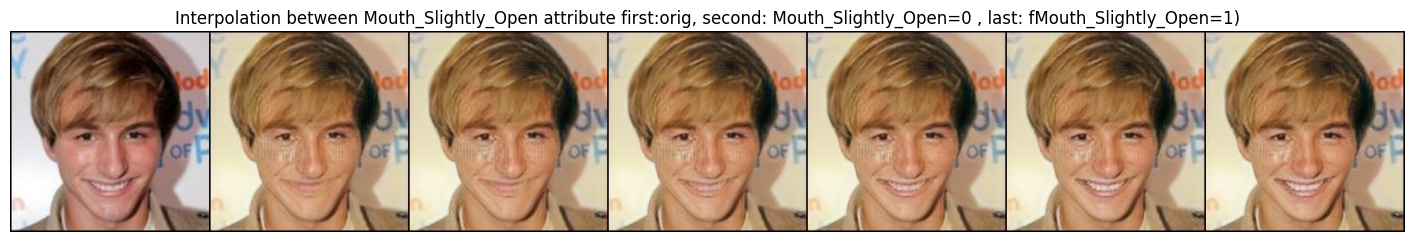

In [423]:
show_exp(attr="Mouth_Slightly_Open", count=6)

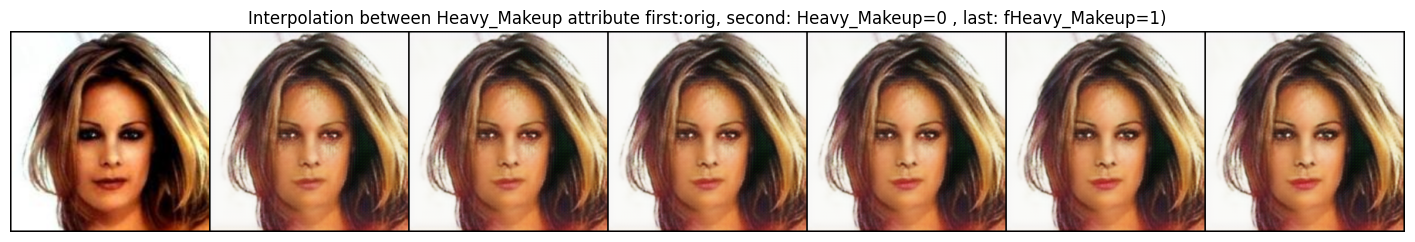

In [435]:
show_exp(attr="Heavy_Makeup", count=6)

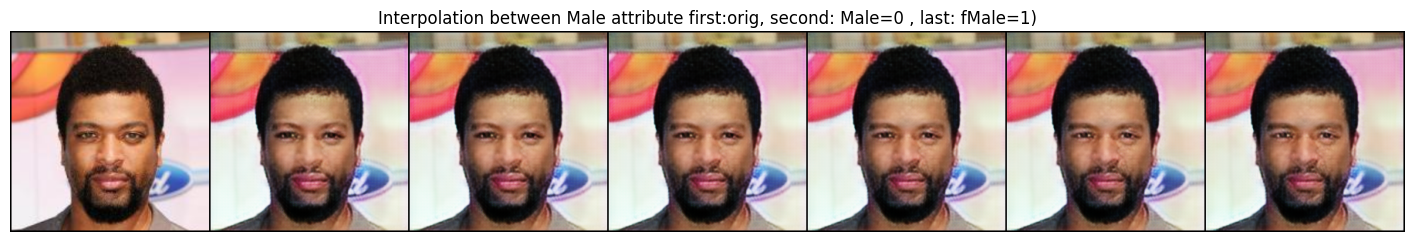

In [459]:
show_exp(attr="Male", count=6)

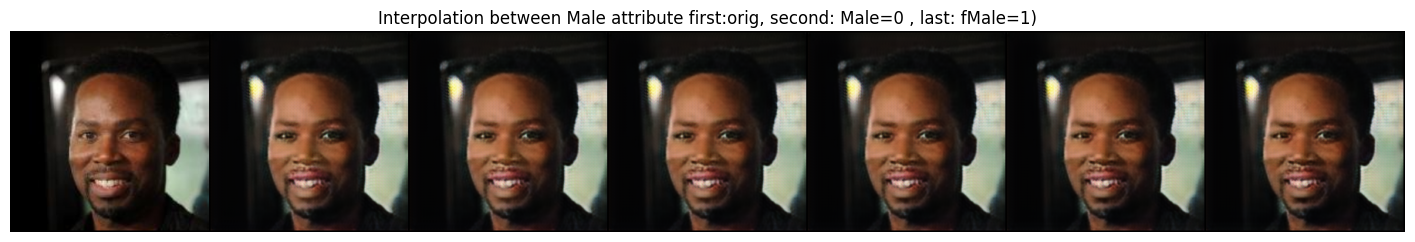

In [470]:
show_exp(attr="Male", count=6)

В целом, гладкость есть. Особенно это заметно на каких-то более частных атрибутах, типа приоткрытый рот: при alpha = 0 на картинках рот просто закрыт, а при увеличении alpha он приоткрывается, показываются зубы и к alpha = 1 уже полноценно приоткрытый рот. С другими аттрибутами менее заметно. 

Эксперименировал еще с латентами в генераторе (после downsampling) - никаких результатов особо не получилось, поэтому не стал приводить, поскольку версия 1 и латентного пространства тут нет, то не оч понятно что можно было бы еще пробовать. 


**Изменения в модели**:

1) Как-то лучше работать с генерацией стилей при обучении, сейчас используется сдвиг по батчу (то есть если у изображения был набор стилей [1, 0, 0, 1, 0], а у второго в батче был [0, 1, 0, 0, 0], то теперь у первого станет набор стилей второго. Это не всегда удобно, потому что могут быть либо супер конфликтующие аттрибуты, либо вообще остаться +- одинаковыми, а хочется как-то разнообразить. Например, если на фото белые волосы, то хочется взять аттрибут -  покрасить в черный или что-то такое и сосредоточиться исключительно на 2-3аттрибутах, у нас же может быть слишком много их и не все могут быть важны.
2) Опять с аттрибутами: у нас есть аттрибуты достаточно редкие, хотя вполне понятные (типа головной убор, очки и тд), и вот модель на них не выучилась, пока не умеет дорисовывать их: возможно это связано с редкими аттрибутами. Можно было показывать на обучении чаще сэмплы с редкими аттрибутами, чтобы модель на них обучилась быстрее, чем просто ждать 5к часов, либо добавить вес таким изображениям. Тогда вероятно на такие вещи можно быстрее обучиться, но опять же тут надо еще применять идеи из первого пункта, чтобы как-то хорошо сэпмлировать аттрибуты новые, а не просто случайным образом или по батчу 